# Are Tool Latency and Frequency an Opportunity to Hide Latency and Interleave Requests?

**Question.** Agents leave the accelerator idle while tools run and humans think. Can we park a request's KV cache in cheaper memory during those gaps, run someone else's decode, and reload in time, and if so, which policy is fastest and which is cheapest?

**Method.** Monte-Carlo simulation of agentic sessions calibrated on the TraceLab trace (UW, 4,265 Claude Code / Codex sessions) and the internal *Unit Economics and Architecture: First Pass* deck. We compare KV placement policies across memory tiers, then sweep the design space (generation speed, tool latency, ISL, tier choice, eviction threshold) and extract the Pareto frontier of speed vs cost.

**Calibration anchors (median scenario)**
- LLM generation per step: median 4.9-5.7 s (we use 5.3 s), heavy-tailed (avg ~11.5 s)
- Tool execution per step: median 0.1-0.3 s, avg 16.8 s
- Tool mixture: calls <1 s are ~70% of calls but <1% of tool time; calls >1 min are ~4.9% of calls and ~92% of tool time
- Steps per request ~8.7; tool calls per step ~1.2; human gap between requests: median 1.4 min, heavy tail (capped at 1 h as in TraceLab)
- Model: Kimi K3 (2.8T total / 104B active), hybrid attention: 69 KDA layers (constant ~0.5 GB state) + 24 Gated MLA layers (576 B/token FP8 latent) -> KV = ISL x 24 x 576 B + 0.5 GB, i.e. 13.8 GB + 0.5 GB at 1M ISL; ISL median 140K, max 1M
- Memory $/GB/hr (mid-2026): SRAM 0.0182, HBM4e 0.0025, LPDDR5X 0.0019, DDR5 0.0018, SSD 0.0012
- SSD tier: 4x Gen5 NVMe stripe ~52 GB/s read; host DDR5 over PCIe5 x16 ~55 GB/s effective


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

P = dict(
    # --- per-step LLM generation (seconds) ---
    gen_median_s   = 5.3,      # TraceLab individual LLM span median 5.7s / per-step p50 4.9s
    gen_sigma      = 1.245,    # lognormal sigma -> mean ~11.5s, matches trace avg

    # --- tool latency mixture (3 lognormal buckets, calibrated below) ---
    tool_share_calls = np.array([0.70, 0.251, 0.049]),   # <1s | 1-60s | >60s
    tool_share_time  = np.array([0.01, 0.07,  0.92 ]),   # share of total tool time
    tool_mean_s      = 16.8,                             # trace average tool latency
    tool_sigma       = np.array([1.18, 1.31, 1.39]),

    # --- loop structure ---
    calls_per_step   = 1.2,    # 80% one call, 20% two sequential calls
    steps_per_request= 8.7,    # -> P(human gap at step end) = 1/8.7
    human_median_s   = 84.0,   # 1.4 min
    human_sigma      = 2.65,   # -> uncapped mean ~46 min
    human_cap_s      = 3600.0, # cap idle at 1h (TraceLab "human capped" view)
    out_tokens_step  = 250,    # median output tokens per step

    # --- model & KV footprint (Kimi K3: hybrid KDA + MLA, FP8 KV) ---
    # 93 text-backbone layers: 69 KDA (constant-size recurrent state, does
    # NOT scale with tokens) + 24 Gated MLA (576-dim latent/token, FP8).
    # KV(ISL) = ISL x 24 x 576 B + 0.5 GB KDA state -> 13.8+0.5 GB @1M.
    n_mla_layers     = 24,
    mla_latent_bytes = 576,    # 512 nope + 64 rope dims x FP8 (1 B)
    kda_state_gb     = 0.5,    # constant per request; stored for exact reuse
    isl_tokens       = 140e3,
    isl_max_tokens   = 1e6,

    # --- memory tiers: effective reload bandwidth to HBM (GB/s) and $/GB/hr ---
    tiers = dict(
        HBM = dict(bw=np.inf, price=0.0025),   # resident: no reload
        DDR = dict(bw=55.0,   price=0.0018),   # host DDR5 over PCIe5 x16
        SSD = dict(bw=52.0,   price=0.0012),   # 4x Gen5 NVMe stripe (read)
    ),
    reload_overlap = 0.5,      # fraction of reload hidden by layer-order streaming
    write_bw       = 45.0,     # GB/s stripe write (append-only journaling, tiny traffic)

    # --- system / cost model ---
    hbm_kv_budget_GB = 150.0,  # per-accelerator HBM available for KV (after weights)
    batch_max        = 128,    # compute ceiling on concurrent resident decodes
    chip_price_hr    = 0.98,   # GB300-class all-in $/chip/hr (deck assumption, 0% GM)
    stripe_util      = 0.70,   # usable fraction of stripe bandwidth

    # --- predictor for gap duration (semantic + history) ---
    pred_sigma = 0.6,          # lognormal noise on predicted gap (x/÷ ~1.8 at 1 sigma)
)

def kv_footprint_GB(isl, Pl=None):
    Pl = Pl or P
    return isl * Pl["n_mla_layers"] * Pl["mla_latent_bytes"] / 1e9 + Pl["kda_state_gb"]

kv_GB      = kv_footprint_GB(P["isl_tokens"])
kv_GB_max  = kv_footprint_GB(P["isl_max_tokens"])
print(f"KV footprint @140K ISL: {kv_GB:.2f} GB   |   @1M ISL: {kv_GB_max:.1f} GB")
for name, t in P["tiers"].items():
    if np.isfinite(t["bw"]):
        print(f"reload {name}: {kv_GB/t['bw']*1e3:6.0f} ms @140K   {kv_GB_max/t['bw']*1e3:6.0f} ms @1M")


KV footprint @140K ISL: 2.44 GB   |   @1M ISL: 14.3 GB
reload DDR:     44 ms @140K      260 ms @1M
reload SSD:     47 ms @140K      275 ms @1M


## 1. Workload model

Tool latency is a 3-bucket lognormal mixture calibrated so that (i) bucket call-shares match 70 / 25.1 / 4.9 %, (ii) bucket time-shares match 1 / 7 / 92 %, and (iii) the overall mean is 16.8 s. Bucket means follow directly: `mean_b = time_share_b x 16.8 / call_share_b` giving ~0.24 s, ~4.7 s, ~315 s. Generation and human gaps are single lognormals matched to trace medians and means.


In [2]:
# bucket means implied by the call/time shares and the overall mean
tool_mu = P["tool_share_time"] * P["tool_mean_s"] / P["tool_share_calls"]
print("tool bucket means (s):", np.round(tool_mu, 2))

def sample_lognorm(mean=None, median=None, sigma=1.0, size=1, rng=rng):
    if median is None:
        median = mean / np.exp(sigma**2 / 2)
    return rng.lognormal(np.log(median), sigma, size)

def sample_tool(size, rng=rng):
    b = rng.choice(3, p=P["tool_share_calls"], size=size)
    out = np.empty(size)
    for i in range(3):
        m = b == i
        out[m] = sample_lognorm(mean=tool_mu[i], sigma=P["tool_sigma"][i], size=m.sum(), rng=rng)
    return out

def sample_gen(size, rng=rng):
    return sample_lognorm(median=P["gen_median_s"], sigma=P["gen_sigma"], size=size, rng=rng)

def sample_human(size, rng=rng):
    return np.minimum(sample_lognorm(median=P["human_median_s"], sigma=P["human_sigma"],
                                     size=size, rng=rng), P["human_cap_s"])

# --- validation against the trace ---
t = sample_tool(400_000); g = sample_gen(400_000); h = sample_human(200_000)
val = pd.DataFrame({
    "metric": ["tool median (s)", "tool mean (s)", "tool <1s call share", "tool <1s time share",
               "tool >60s call share", "tool >60s time share", "gen median (s)", "gen mean (s)",
               "human median (min)"],
    "simulated": [np.median(t), t.mean(), (t<1).mean(), t[t<1].sum()/t.sum(),
                  (t>60).mean(), t[t>60].sum()/t.sum(), np.median(g), g.mean(), np.median(h)/60],
    "trace target": [0.2, 16.8, 0.70, 0.01, 0.049, 0.92, 5.3, 11.5, 1.4],
})
val


tool bucket means (s): [2.4000e-01 4.6900e+00 3.1543e+02]


,metric,simulated,trace target
0,tool median (s),0.2206,0.2
1,tool mean (s),15.98,16.8
2,tool <1s call share,0.7502,0.7
3,tool <1s time share,0.01017,0.01
4,tool >60s call share,0.03426,0.049
5,tool >60s time share,0.8946,0.92
6,gen median (s),5.29,5.3
7,gen mean (s),11.45,11.5
8,human median (min),1.401,1.4


## 2. Placement policies

A step is `generate -> gap (tool or human) -> reload? -> next step`. The GPU needs the KV resident only during generation. Policies decide, at each gap, where the KV waits:

| Policy | Rule |
|---|---|
| **PIN** | never evict; KV occupies HBM through every gap (today's default inside TTL) |
| **EVICT-ALL** | evict to a tier on every gap, reload on return |
| **GATED(tier, k)** | evict iff *predicted* gap > k x reload time; predictor has lognormal noise (semantic + history predictor, TraceLab opp. #3) |
| **TIERED(k)** | gated, but choose tier by predicted gap: DDR for medium gaps, SSD for long/human gaps |

Because KV is **append-only**, the write side is journaled incrementally during decode (~step_growth x KB/token, a few ms of stripe time), so eviction itself is free; only the reload is paid. `reload_overlap` models layer-order streaming that hides part of the reload behind prefill of the appended tool result.


In [3]:
def simulate_user(policy, tier="SSD", k=2.0, kv_GB=kv_GB, n_steps=60_000, seed=0, Pov=None):
    """Simulate one user's step stream; return residency, cost drivers, latency metrics."""
    Pl = dict(P); Pl.update(Pov or {})
    r = np.random.default_rng(seed)
    gen  = sample_lognorm(median=Pl["gen_median_s"], sigma=Pl["gen_sigma"], size=n_steps, rng=r)
    gen *= Pl.get("gen_mult", 1.0)
    ncall = 1 + (r.random(n_steps) < (Pl["calls_per_step"] - 1)).astype(int)
    tool  = sample_tool(n_steps, rng=r) * Pl.get("tool_mult", 1.0)
    tool2 = sample_tool(n_steps, rng=r) * Pl.get("tool_mult", 1.0)
    gap   = np.where(ncall == 2, tool + tool2, tool)
    is_human = r.random(n_steps) < 1.0 / Pl["steps_per_request"]
    hgap  = np.minimum(sample_lognorm(median=Pl["human_median_s"], sigma=Pl["human_sigma"],
                                      size=n_steps, rng=r), Pl["human_cap_s"])
    gap   = np.where(is_human, gap + hgap, gap)

    tiers = Pl["tiers"]
    rl = {n: (kv_GB / t["bw"] if np.isfinite(t["bw"]) else 0.0) for n, t in tiers.items()}
    pred = gap * r.lognormal(0.0, Pl["pred_sigma"], n_steps)

    if policy == "PIN":
        park = np.zeros(n_steps, bool); park_tier = np.full(n_steps, "HBM")
    elif policy == "EVICT-ALL":
        park = np.ones(n_steps, bool);  park_tier = np.full(n_steps, tier)
    elif policy == "GATED":
        park = pred > k * rl[tier];     park_tier = np.full(n_steps, tier)
    elif policy == "TIERED":
        to_ssd = (pred > k * rl["SSD"]) & (is_human | (pred > 60.0))
        to_ddr = (pred > k * rl["DDR"]) & ~to_ssd
        park = to_ssd | to_ddr
        park_tier = np.where(to_ssd, "SSD", np.where(to_ddr, "DDR", "HBM"))
    else:
        raise ValueError(policy)

    reload_t = np.where(park, np.vectorize(rl.get)(park_tier), 0.0)
    added    = reload_t * (1 - Pl["reload_overlap"])          # visible extra TTFT
    hbm_t    = gen + np.where(park, reload_t, gap)            # HBM occupied: gen + unparked gaps + reloads
    wall     = gen + gap + added

    parked_share = {n: gap[park & (park_tier == n)].sum() / wall.sum() for n in ("DDR", "SSD")}
    reloads_hr   = park.sum() / (wall.sum() / 3600)
    return dict(
        policy=f"{policy}" + (f"({tier},k={k:g})" if policy == "GATED" else (f"(k={k:g})" if policy=="TIERED" else "")),
        residency = hbm_t.sum() / wall.sum(),
        parked_DDR = parked_share["DDR"], parked_SSD = parked_share["SSD"],
        reloads_per_hr = reloads_hr,
        added_ttft_ms = 1e3 * added[park].mean() if park.any() else 0.0,
        req_resp_s = (gen + np.where(is_human, gap - hgap, gap) + added).sum() / is_human.sum(),
        steps_per_hr = 3600 / wall.mean(),
        miss_wasted_ms = 1e3 * np.where(park & (gap < reload_t), reload_t, 0).mean(),
    )

runs = [simulate_user("PIN"),
        simulate_user("EVICT-ALL", tier="SSD"),
        simulate_user("GATED", tier="DDR", k=2),
        simulate_user("GATED", tier="SSD", k=2),
        simulate_user("TIERED", k=2)]
base = pd.DataFrame(runs).set_index("policy")
base


,residency,parked_DDR,parked_SSD,reloads_per_hr,added_ttft_ms,req_resp_s,steps_per_hr,miss_wasted_ms
policy,,,,,,,,
PIN,1,0,0,0,0,276.7,36,0
EVICT-ALL,0.1158,0,0.8845,35.99,23.42,276.9,35.99,5.01
"GATED(DDR,k=2)",0.1158,0.8844,0,28.21,22.14,276.9,35.99,0.1432
"GATED(SSD,k=2)",0.1158,0,0.8844,27.87,23.42,276.9,35.99,0.1631
TIERED(k=2),0.1158,0.01885,0.8655,28.21,22.39,276.9,35.99,0.1432


## 3. System view: concurrency, bandwidth, cost

Per accelerator: `users = min(HBM_KV_budget / kv_GB / residency, batch_max)`. The stripe must sustain `users x kv_GB x reloads_per_hr / 3600` GB/s of reload reads. Cost per M output tokens combines the accelerator share, the HBM occupied, and the parked bytes in DDR/SSD:

`$/Mtok = (chip_price/users + kv_GB x [residency x p_HBM + parked_DDR x p_DDR + parked_SSD x p_SSD]) / tokens_per_user_hr x 1e6`


In [4]:
def system_view(row, kv_GB=kv_GB, Pl=P):
    tiers = Pl["tiers"]
    u_hbm  = Pl["hbm_kv_budget_GB"] / kv_GB / row["residency"]
    users  = min(u_hbm, Pl["batch_max"])
    stripe_need = users * kv_GB * row["reloads_per_hr"] / 3600
    stripe_ok   = stripe_need <= 52.0 * Pl["stripe_util"]
    tok_hr = row["steps_per_hr"] * Pl["out_tokens_step"]
    mem = kv_GB * (row["residency"] * tiers["HBM"]["price"]
                   + row["parked_DDR"] * tiers["DDR"]["price"]
                   + row["parked_SSD"] * tiers["SSD"]["price"])
    accel = Pl["chip_price_hr"] / users
    return pd.Series(dict(users_per_chip=users, hbm_bound=u_hbm, stripe_GBps=stripe_need,
                          stripe_ok=stripe_ok, tok_per_user_hr=tok_hr,
                          cost_per_Mtok=(accel + mem) / tok_hr * 1e6,
                          accel_share=accel / (accel + mem)))

sysv = base.join(base.apply(system_view, axis=1))
cols = ["residency","users_per_chip","stripe_GBps","added_ttft_ms","req_resp_s","cost_per_Mtok"]
sysv[cols].sort_values("cost_per_Mtok")


,residency,users_per_chip,stripe_GBps,added_ttft_ms,req_resp_s,cost_per_Mtok
policy,,,,,,
"GATED(SSD,k=2)",0.1158,128,2.413,23.42,276.9,1.216
EVICT-ALL,0.1158,128,3.117,23.42,276.9,1.216
TIERED(k=2),0.1158,128,2.442,22.39,276.9,1.219
"GATED(DDR,k=2)",0.1158,128,2.442,22.14,276.9,1.36
PIN,1,61.59,0,0,276.7,2.444


## 4. Design-space sweeps

Four directions: (a) eviction threshold *k* (how aggressive to park), (b) faster LLM generation (Cerebras-like interactivity), (c) slower/denser tools (computer-use agents, heavier sandboxes), (d) context scale 140K vs 1M and tier choice.


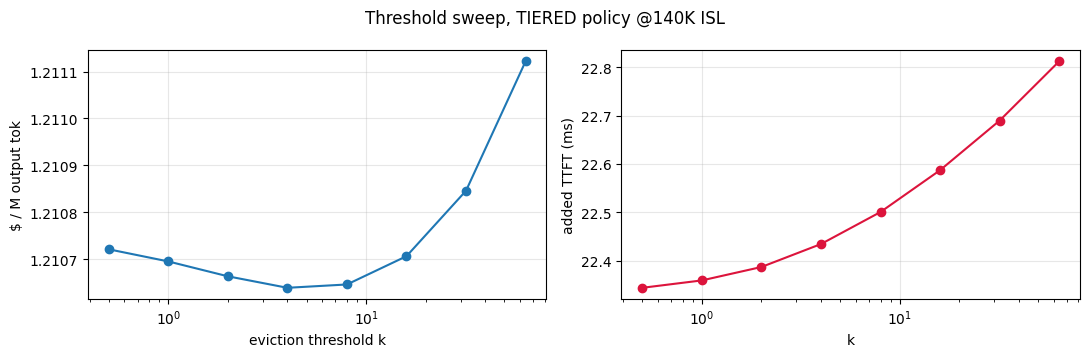

local optimum: k=4  ->  $1.211/Mtok, +22 ms TTFT, 128 users/chip


In [5]:
ks = np.array([0.5, 1, 2, 4, 8, 16, 32, 64])
rows = []
for k in ks:
    r = simulate_user("TIERED", k=k, seed=3)
    rows.append(dict(k=k, **system_view(pd.Series(r)).to_dict(),
                     added_ttft_ms=r["added_ttft_ms"], residency=r["residency"]))
sw = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].semilogx(sw.k, sw.cost_per_Mtok, "o-"); ax[0].set_xlabel("eviction threshold k"); ax[0].set_ylabel("$ / M output tok")
ax[1].semilogx(sw.k, sw.added_ttft_ms, "o-", color="crimson"); ax[1].set_xlabel("k"); ax[1].set_ylabel("added TTFT (ms)")
for a in ax: a.grid(alpha=.3)
fig.suptitle("Threshold sweep, TIERED policy @140K ISL"); plt.tight_layout(); plt.show()
kopt = sw.loc[sw.cost_per_Mtok.idxmin()]
print(f"local optimum: k={kopt.k:g}  ->  ${kopt.cost_per_Mtok:.3f}/Mtok, +{kopt.added_ttft_ms:.0f} ms TTFT, {kopt.users_per_chip:.0f} users/chip")


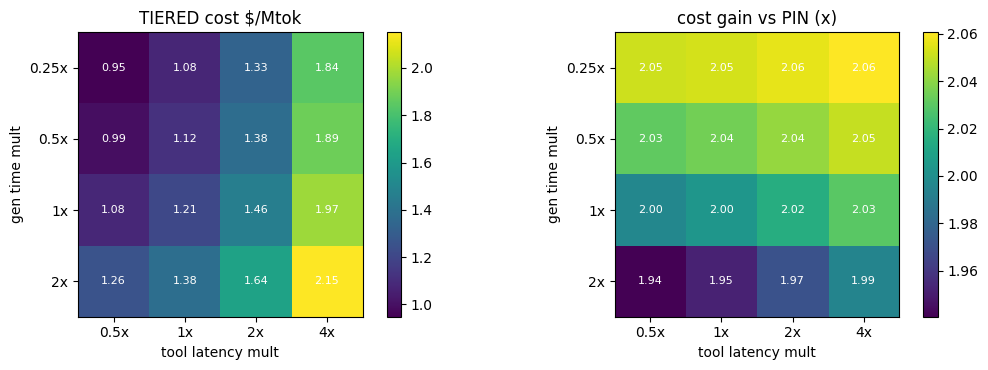

Interleaving pays MORE when generation gets faster and tools get slower: idle share grows either way.


In [6]:
gen_mults  = [0.25, 0.5, 1, 2]      # 0.25 = 4x faster generation (wafer-scale-like)
tool_mults = [0.5, 1, 2, 4]         # 4 = much slower tools (browser/computer-use agents)
cost = np.zeros((len(gen_mults), len(tool_mults))); gain = cost.copy()
for i, gm in enumerate(gen_mults):
    for j, tm in enumerate(tool_mults):
        ov = dict(gen_mult=gm, tool_mult=tm)
        tier_r = simulate_user("TIERED", k=2, seed=5, Pov=ov)
        pin_r  = simulate_user("PIN",            seed=5, Pov=ov)
        cost[i, j] = system_view(pd.Series(tier_r))["cost_per_Mtok"]
        gain[i, j] = system_view(pd.Series(pin_r))["cost_per_Mtok"] / cost[i, j]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for M, a, ttl in ((cost, ax[0], "TIERED cost $/Mtok"), (gain, ax[1], "cost gain vs PIN (x)")):
    im = a.imshow(M, cmap="viridis"); plt.colorbar(im, ax=a)
    a.set_xticks(range(len(tool_mults)), [f"{t}x" for t in tool_mults]); a.set_xlabel("tool latency mult")
    a.set_yticks(range(len(gen_mults)), [f"{g}x" for g in gen_mults]);  a.set_ylabel("gen time mult")
    a.set_title(ttl)
    for ii in range(M.shape[0]):
        for jj in range(M.shape[1]): a.text(jj, ii, f"{M[ii,jj]:.2f}", ha="center", va="center", color="w", fontsize=8)
plt.tight_layout(); plt.show()
print("Interleaving pays MORE when generation gets faster and tools get slower: idle share grows either way.")


In [7]:
rows = []
for isl, label in [(140e3, "140K"), (1e6, "1M")]:
    kvG = kv_footprint_GB(isl)
    for pol, kw in [("PIN", {}), ("GATED", dict(tier="DDR", k=2)), ("GATED", dict(tier="SSD", k=2)), ("TIERED", dict(k=2))]:
        r = simulate_user(pol, kv_GB=kvG, seed=9, **kw)
        s = system_view(pd.Series(r), kv_GB=kvG)
        rows.append(dict(ISL=label, policy=r["policy"], kv_GB=kvG, **s.to_dict(),
                         added_ttft_ms=r["added_ttft_ms"]))
isl_df = pd.DataFrame(rows)
isl_df[["ISL","policy","kv_GB","users_per_chip","stripe_GBps","added_ttft_ms","cost_per_Mtok"]]


,ISL,policy,kv_GB,users_per_chip,stripe_GBps,added_ttft_ms,cost_per_Mtok
0,140K,PIN,2.435,61.59,0,0,2.391
1,140K,"GATED(DDR,k=2)",2.435,128,2.497,22.14,1.331
2,140K,"GATED(SSD,k=2)",2.435,128,2.467,23.42,1.192
3,140K,TIERED(k=2),2.435,128,2.497,22.39,1.195
4,1M,PIN,14.32,10.47,0,0,14.06
5,1M,"GATED(DDR,k=2)",14.32,85.83,5.905,130.2,4.181
6,1M,"GATED(SSD,k=2)",14.32,85.77,5.798,137.7,3.361
7,1M,TIERED(k=2),14.32,85.82,5.904,132.6,3.377


## 5. Fastest vs cheapest: the Pareto frontier

Speed = mean request response time (generation + tool wait + visible reload penalty; human gaps excluded, as the user causes them). Cost = $/M output tokens. Points on the lower-left frontier dominate.


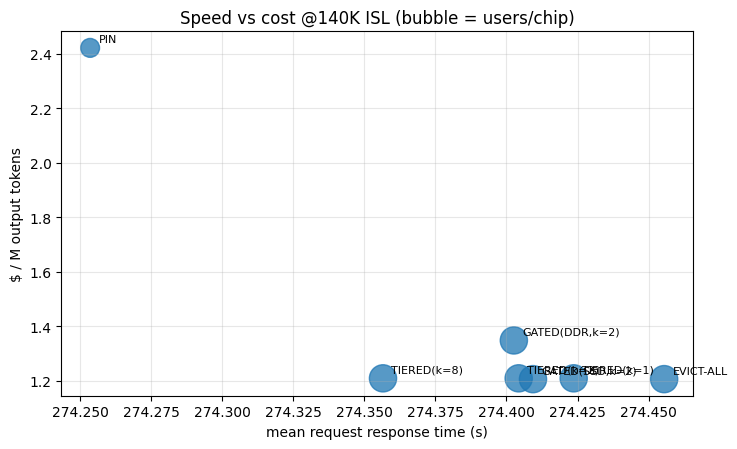

,policy,resp_s,cost,users
3,"GATED(SSD,k=2)",274.4,1.205,128
1,EVICT-ALL,274.5,1.205,128
6,TIERED(k=8),274.4,1.208,128
5,TIERED(k=2),274.4,1.208,128
4,TIERED(k=1),274.4,1.208,128
2,"GATED(DDR,k=2)",274.4,1.347,128
0,PIN,274.3,2.422,61.59


In [8]:
cands = []
for pol, kw in [("PIN", {}), ("EVICT-ALL", dict(tier="SSD")),
                ("GATED", dict(tier="DDR", k=2)), ("GATED", dict(tier="SSD", k=2)),
                ("TIERED", dict(k=1)), ("TIERED", dict(k=2)), ("TIERED", dict(k=8))]:
    r = simulate_user(pol, seed=11, **kw)
    s = system_view(pd.Series(r))
    cands.append(dict(policy=r["policy"], resp_s=r["req_resp_s"], cost=s["cost_per_Mtok"],
                      users=s["users_per_chip"]))
pf = pd.DataFrame(cands)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.scatter(pf.resp_s, pf.cost, s=pf.users*3, alpha=.75)
for _, r in pf.iterrows():
    ax.annotate(r.policy, (r.resp_s, r.cost), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("mean request response time (s)"); ax.set_ylabel("$ / M output tokens")
ax.set_title("Speed vs cost @140K ISL (bubble = users/chip)"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
pf.sort_values("cost")


## 6. Conclusions

Printed from the simulation so they update with the assumptions:


In [9]:
tiered = simulate_user("TIERED", k=2, seed=1); tv = system_view(pd.Series(tiered))
best = pf.loc[pf.cost.idxmin()]; pin = pf[pf.policy=="PIN"].iloc[0]
print(f"""ANSWER: YES — tool structure is a schedulable resource, with one condition.

1. Opportunity size. Gated tiering needs the KV in HBM only {tiered['residency']:.0%} of wall
   time vs 100% for PIN -> {tv['users_per_chip']:.0f} users/chip (batch-ceiling bound) vs {pin.users:.0f}.
2. The median tool call (~0.2 s) is NOT the opportunity: shorter than any reload.
   The opportunity is the 4.9% of calls >1 min (92% of tool time) plus human gaps.
   Gating on PREDICTED gap length is what separates the win from a loss;
   mispredictions cost only ~{tiered['miss_wasted_ms']:.0f} ms of wasted reload per step on average.
3. Cheapest: {best.policy} at ${best.cost:.3f}/Mtok, {pin.cost/best.cost:.1f}x cheaper than PIN
   (${pin.cost:.3f}). Fastest remains PIN by ~{(best.resp_s-pin.resp_s):.1f} s/request: gated policies
   give up only the reload tail, so the speed-cost frontier is short.
4. Tier choice barely moves cost at 140K ISL (reload ~45 ms either way); at 1M ISL
   (14.3 GB KV) reloads reach ~0.26-0.28 s and STRIPE BANDWIDTH, not $/GB, becomes the
   binding constraint (see ISL table: stripe_ok flips false as users scale).
5. Direction of travel: faster generation (wafer-scale interactivity) and slower,
   denser tools (computer-use agents) BOTH raise the idle share and widen the gain
   vs PIN (heatmap). The trend makes interleaving matter more, not less.
""")


ANSWER: YES — tool structure is a schedulable resource, with one condition.

1. Opportunity size. Gated tiering needs the KV in HBM only 11% of wall
   time vs 100% for PIN -> 128 users/chip (batch-ceiling bound) vs 62.
2. The median tool call (~0.2 s) is NOT the opportunity: shorter than any reload.
   The opportunity is the 4.9% of calls >1 min (92% of tool time) plus human gaps.
   Gating on PREDICTED gap length is what separates the win from a loss;
   mispredictions cost only ~0 ms of wasted reload per step on average.
3. Cheapest: GATED(SSD,k=2) at $1.205/Mtok, 2.0x cheaper than PIN
   ($2.422). Fastest remains PIN by ~0.2 s/request: gated policies
   give up only the reload tail, so the speed-cost frontier is short.
4. Tier choice barely moves cost at 140K ISL (reload ~45 ms either way); at 1M ISL
   (14.3 GB KV) reloads reach ~0.26-0.28 s and STRIPE BANDWIDTH, not $/GB, becomes the
   binding constraint (see ISL table: stripe_ok flips false as users scale).
5. Direction of trav